TEST

In [62]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit.Chem import rdmolops

from matplotlib import pyplot as plt
import pandas as pd
import gzip

In [74]:
suppl_ligs = Chem.SDMolSupplier('./montpellier_ligands_ligprep.sdf')
prepped3D = [x for x in suppl_ligs if x is not None]

suppl_decoys = Chem.SmilesMolSupplier('./decoys/decoys_25700/decoys/decoys_to_build.smi')
unprepped_decoys = [x for x in suppl_decoys if x is not None]

In [98]:
df_montpellier = PandasTools.LoadSDF('./montpellier_ligands_ligprep.sdf', smilesName='SMILES')

df_montpellier= df_montpellier[['ID', 'ROMol','SMILES']]
df_montpellier['Source'] = 'Montpellier'

df_montpellier['MolLogP'] = df_montpellier['ROMol'].apply(lambda x: Descriptors.MolLogP(x))
df_montpellier['MolWt'] = df_montpellier['ROMol'].apply(lambda x: Descriptors.MolWt(x))
df_montpellier['NumHAcceptors'] = df_montpellier['ROMol'].apply(lambda x: Descriptors.NumHAcceptors(x))
df_montpellier['NumHDonors'] = df_montpellier['ROMol'].apply(lambda x: Descriptors.NumHDonors(x))
df_montpellier['NumRotatableBonds'] = df_montpellier['ROMol'].apply(lambda x: Descriptors.NumRotatableBonds(x))
df_montpellier['FormalCharge'] = df_montpellier['ROMol'].apply(lambda x: Chem.GetFormalCharge(x))

df_montpellier.head()

Failed to patch pandas - unable to change molecule rendering


,ID,ROMol,SMILES,Source,MolLogP,MolWt,NumHAcceptors,NumHDonors,NumRotatableBonds,FormalCharge
0,RR1_Rahimova_2017,<rdkit.Chem.rdchem.Mol object at 0x18f8b2180>,COc1ccc(NC(=O)CSc2nc(-c3cccnc3)nn2CC(=O)NNC(=O...,Montpellier,2.55790,577.623,11,3,11,0
1,RR2_Rahimova_2017,<rdkit.Chem.rdchem.Mol object at 0x18f8b20a0>,COc1ccc(C(=O)NNC(=O)CSc2nnc(-c3ccc(NS(=O)(=O)c...,Montpellier,4.61402,658.762,10,3,11,0
2,RR3_Rahimova_2017,<rdkit.Chem.rdchem.Mol object at 0x18f8b1fc0>,c1ccc(-c2ccc(-c3nc(-c4c[nH]c5ccccc45)[nH]c3-c3...,Montpellier,9.22600,487.606,1,2,5,0
3,RR4_Rahimova_2017,<rdkit.Chem.rdchem.Mol object at 0x18f8b1f50>,COc1ccc(-c2cc(-c3ccc(OC)cc3)c(C#N)c(SCC(=O)Nc3...,Montpellier,6.84726,566.708,8,1,8,0
4,RR5_Rahimova_2017,<rdkit.Chem.rdchem.Mol object at 0x18f8b0ac0>,O=C(C[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)O...,Montpellier,6.47670,596.683,4,3,10,0


In [99]:
df_decoys_25700 = pd.DataFrame(unprepped_decoys)
df_decoys_25700["ID"] = df_decoys_25700[0].apply(lambda x: x.GetProp('_Name')) 
df_decoys_25700['ROMol'] = df_decoys_25700[0]
df_decoys_25700['SMILES'] = df_decoys_25700[0].apply(lambda x: Chem.MolToSmiles(x))
df_decoys_25700['Source'] = 'Decoys_25700'
df_decoys_25700['MolLogP'] = df_decoys_25700[0].apply(lambda x: Descriptors.MolLogP(x))
df_decoys_25700['MolWt'] = df_decoys_25700[0].apply(lambda x: Descriptors.MolWt(x))
df_decoys_25700['NumHAcceptors'] = df_decoys_25700[0].apply(lambda x : Descriptors.NumHAcceptors(x))
df_decoys_25700['NumHDonors'] = df_decoys_25700[0].apply(lambda x: Descriptors.NumHDonors(x))
df_decoys_25700['NumRotatableBonds'] = df_decoys_25700[0].apply(lambda x: Descriptors.NumRotatableBonds(x))
df_decoys_25700['FormalCharge'] = df_decoys_25700[0].apply(lambda x: Chem.GetFormalCharge(x))

df_decoys_25700 = df_decoys_25700[['ID', 'ROMol', 'SMILES', 'Source', 'MolLogP', 'MolWt', 'NumHAcceptors', 'NumHDonors', 'NumRotatableBonds', 'FormalCharge']]
df_decoys_25700.head()


,ID,ROMol,SMILES,Source,MolLogP,MolWt,NumHAcceptors,NumHDonors,NumRotatableBonds,FormalCharge
0,ZINC100034590,<rdkit.Chem.rdchem.Mol object at 0x18f5118c0>,O=S(=O)(F)C(F)(F)C(F)(F)O[C@@](F)(C(F)(F)F)C(F...,Decoys_25700,4.4805,484.108,4,0,7,0
1,ZINC100043079,<rdkit.Chem.rdchem.Mol object at 0x18f511930>,FC(F)(F)C(F)(F)C(F)(F)C1(F)C(F)(F)C(F)(F)C(F)(...,Decoys_25700,5.7177,450.063,0,0,2,0
2,ZINC100045963,<rdkit.Chem.rdchem.Mol object at 0x18f511a10>,CCCCCOc1ccc(C=C2c3cc([N+](=O)[O-])cc([N+](=O)[...,Decoys_25700,6.4577,520.454,9,0,10,0
3,ZINC100046143,<rdkit.Chem.rdchem.Mol object at 0x18f511af0>,C=CC(=O)OCCCCCC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)...,Decoys_25700,6.0148,460.230,2,0,11,0
4,ZINC100050078,<rdkit.Chem.rdchem.Mol object at 0x18f511850>,CCOC(=O)COc1ccc(C(C2C(=O)CC(C)(C)CC2=O)C2C(=O)...,Decoys_25700,3.8695,500.588,8,0,8,0


,ID,ROMol,SMILES,Source,MolLogP,MolWt,NumHAcceptors,NumHDonors,NumRotatableBonds,FormalCharge
3960,ZINC97939684,<rdkit.Chem.rdchem.Mol object at 0x18f598660>,CCOc1cc([C@@H]2C(C(=O)OCCOC)=C(C)NC3=C2C(=O)C[...,Decoys_25700,4.3118,528.583,10,2,9,0


In [59]:
Chem.GetFormalCharge(prepped3D[0])

0

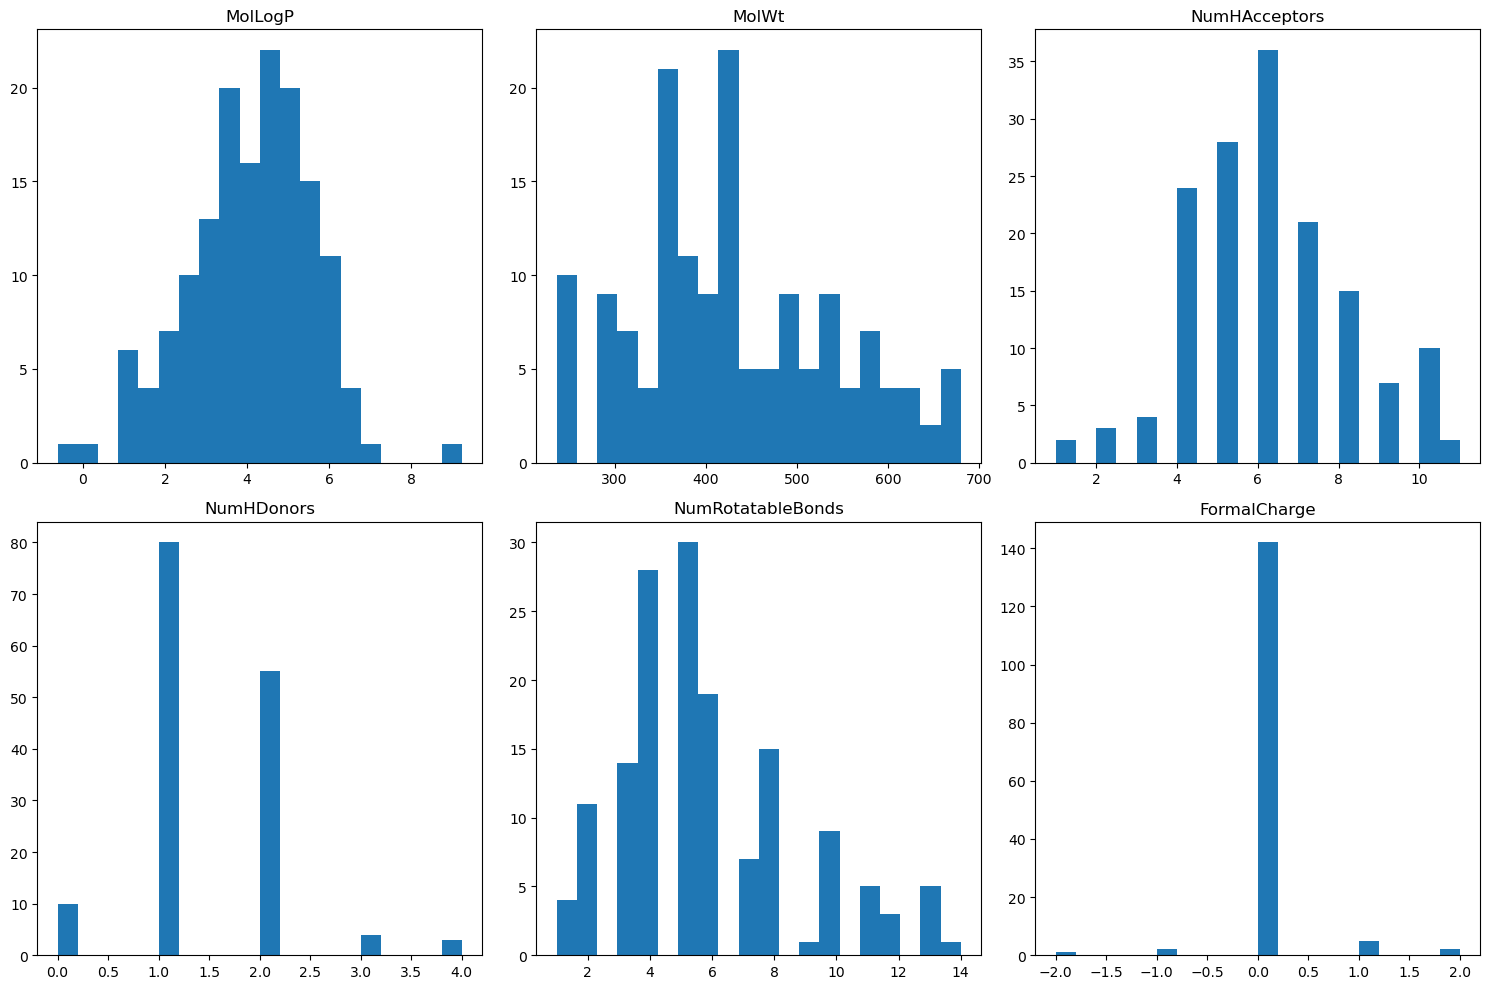

In [100]:
fig, ax = plt.subplots(2,3, figsize=(15,10))
ax[0,0].hist(df_montpellier['MolLogP'], bins=20)
ax[0,0].set_title('MolLogP')
ax[0,1].hist(df_montpellier['MolWt'], bins=20)
ax[0,1].set_title('MolWt')
ax[0,2].hist(df_montpellier['NumHAcceptors'], bins=20)
ax[0,2].set_title('NumHAcceptors')
ax[1,0].hist(df_montpellier['NumHDonors'], bins=20)
ax[1,0].set_title('NumHDonors')
ax[1,1].hist(df_montpellier['NumRotatableBonds'], bins=20)
ax[1,1].set_title('NumRotatableBonds')
ax[1,2].hist(df_montpellier['FormalCharge'], bins=20)
ax[1,2].set_title('FormalCharge')

plt.tight_layout()
plt.show()


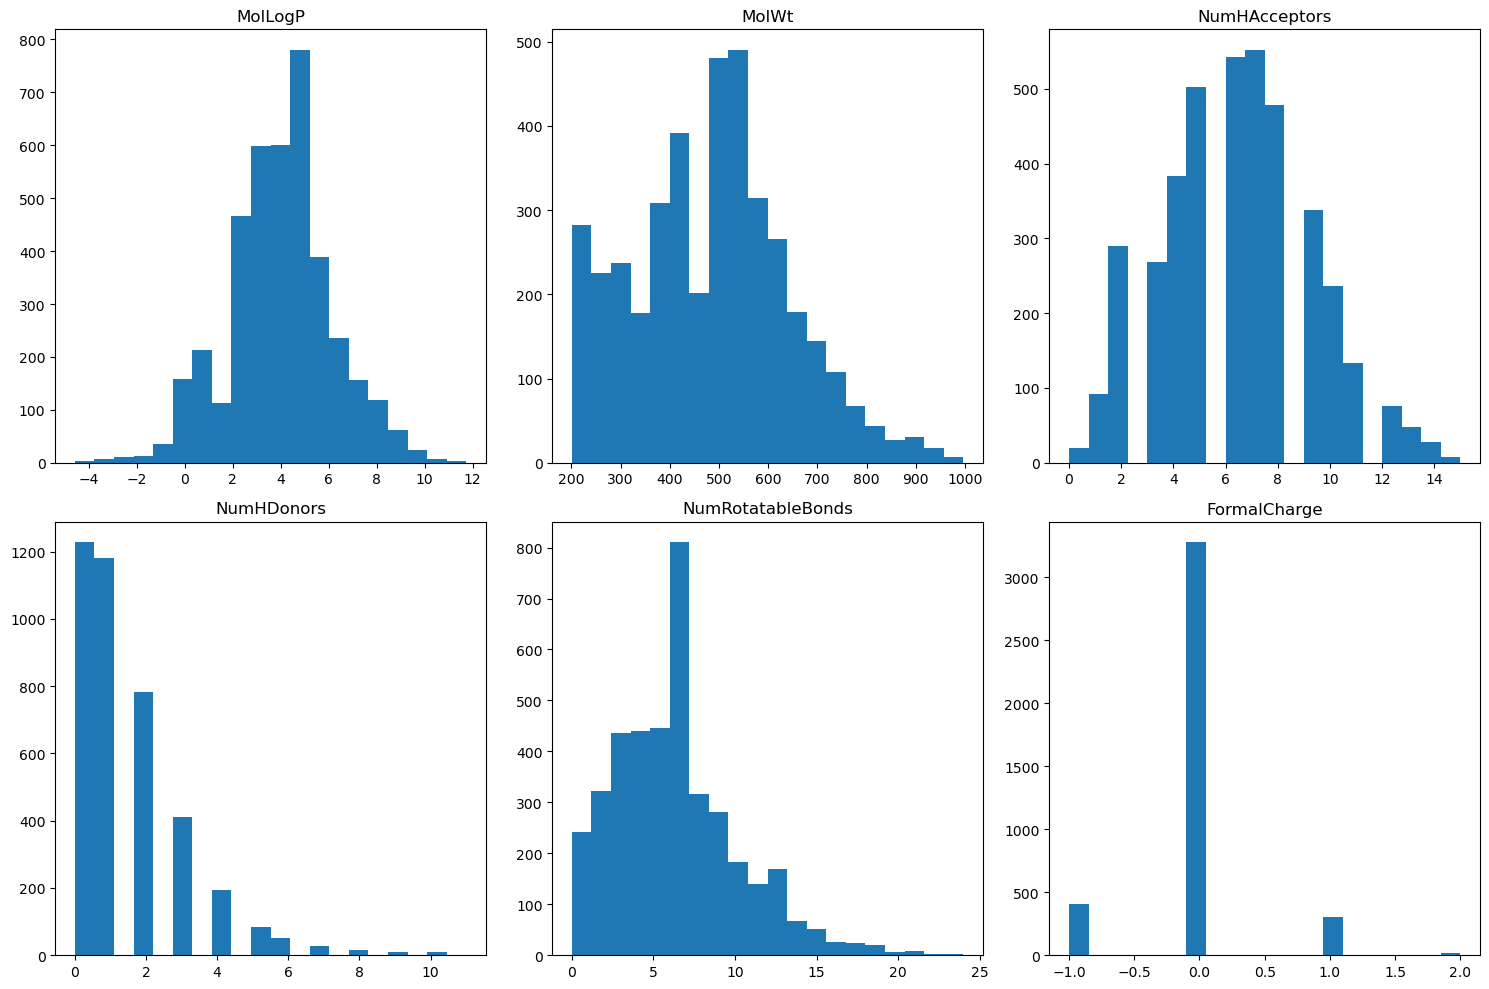

In [101]:
fig, ax = plt.subplots(2,3, figsize=(15,10))
ax[0,0].hist(df_decoys_25700['MolLogP'], bins=20)
ax[0,0].set_title('MolLogP')
ax[0,1].hist(df_decoys_25700['MolWt'], bins=20)
ax[0,1].set_title('MolWt')
ax[0,2].hist(df_decoys_25700['NumHAcceptors'], bins=20)
ax[0,2].set_title('NumHAcceptors')
ax[1,0].hist(df_decoys_25700['NumHDonors'], bins=20)
ax[1,0].set_title('NumHDonors')
ax[1,1].hist(df_decoys_25700['NumRotatableBonds'], bins=20)
ax[1,1].set_title('NumRotatableBonds')
ax[1,2].hist(df_decoys_25700['FormalCharge'], bins=20)
ax[1,2].set_title('FormalCharge')

plt.tight_layout()
plt.show()


In [57]:
len(df)
filtered_df = df[(df['MolLogP'] < 5) & (df['MolWt'] < 500)] #DUDE-Z criteria
strict_filtered_df = filtered_df[(filtered_df['NumHAcceptors'] <= 10) & (filtered_df['NumHDonors'] <= 5) & (filtered_df['NumRotatableBonds'] <= 10)] 

print(f"Original dataset size: {len(df)}")
print(f"Filtered dataset size (DUDE-Z criteria): {len(filtered_df)}")
print(f"Strict filtered dataset size (Lipinski's Rule of Five): {len(strict_filtered_df)}")



Original dataset size: 152
Filtered dataset size (DUDE-Z criteria): 88
Strict filtered dataset size (Lipinski's Rule of Five): 82


# input for DUDE-Z decoy server

Default settings:
```
SMILES YES
PROTONATE YES
MWT 0 125
LOGP 0 3.6
RB 0 5
HBA 0 4
HBD 0 3
CHARGE 0 0
LIGAND TC RANGE 0.0 0.35
MINIMUM DECOYS PER LIGAND 1
DECOYS PER LIGAND 50
MAXIMUM TC BETWEEN DECOYS 0.8
TANIMOTO YES
```

Settings reflecting ligand set (DUDE-Z automatically excludes MW > 500, and logP > 5)
```
SMILES YES
PROTONATE YES
MWT 0 500
LOGP 1 5
RB 0 10
HBA 0 4
HBD 0 10
CHARGE 0 0
LIGAND TC RANGE 0.0 0.35
MINIMUM DECOYS PER LIGAND 1
DECOYS PER LIGAND 50
MAXIMUM TC BETWEEN DECOYS 0.8
TANIMOTO YES
```


In [48]:
#val = Descriptors.CalcMolDescriptors(prepped3D[0])
#val['MolLogP']
#val['MolWt']
#val['NumHAcceptors']
#val['NumHDonors']
#val['NumRotatableBonds']

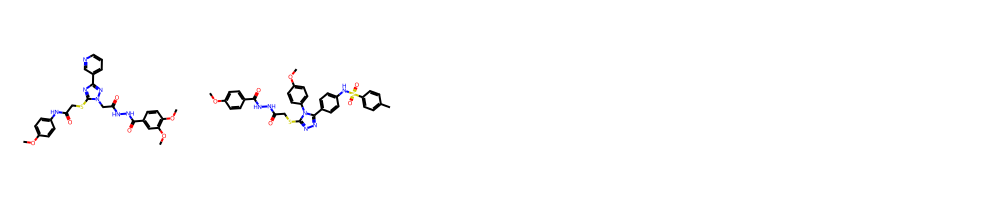

In [49]:
twodims = []

for mol in prepped3D:
    Chem.rdDepictor.Compute2DCoords(mol)
    twodims.append(mol)

img = Draw.MolsToGridImage(twodims[:2], molsPerRow=5, subImgSize=(200,200))

img